# Without advection

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import RK45, solve_ivp
import os
import matplotlib

matplotlib.rcParams['figure.figsize'] = (8,5)
matplotlib.rcParams['font.size']      = 13

In [ ]:
class SN_wrap_v2():
  def __init__(self,n1,n2):

    self.n1    = n1           #E bins
    self.n2    = n2           #Theta bins
    if n1>1:
      self.E     = np.linspace(0,50,n1+1)[:-1]
      self.E    += (self.E[1]-self.E[0])*0.5
    else :
      self.E = np.array([10]).reshape(-1,1)

    if n2>1:
      self.thetas = np.linspace(0,np.pi,n2+1)[:-1] #np.arange(0,np.pi,3)
      self.thetas += (self.thetas[1]-self.thetas[0])*0.5
      #self.thetas = self.thetas.reshape(-1,1)
    else :
      theta_max = np.pi
      theta_min = 0
      self.thetas = np.array([(theta_max - theta_min)/2]).reshape(-1,1)

    self.int_p_theta = 0

    self.I = []
    alpha = 1
    beta = 1.5
    for E_o in self.E:
      self.I.append(np.array([[alpha]*3 + [beta]*3]*self.n2))   #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(self.I).reshape(self.n1,self.n2,6)

    self.t     = None
    self.out   = None

    P0 = []
    for theta_bin in self.thetas:
      P0 += self.P_init(theta_bin)*self.n1   #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

    #self.theta_temp = self.thetas[:,0]
    self.dcost = (np.cos(np.pi) - np.cos(0))/self.n2#(np.cos(self.thetas[-1]) - np.cos(self.thetas[0]))/self.n2#(np.cos(self.theta_temp[self.n2-1]) - np.cos(self.theta_temp[0]))/self.n2

  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,self.n2,6), self.E,self.thetas

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.thetas,self.I)

  def P_init(self,theta):                    # Generates initial values of P and Pbar
    P1 =  [0,0,0.5 + 0.9*np.cos(theta)]
    P2 =  [0,0,0.5 ]#+ 0.1*np.cos(theta)]

    return P1 + P2                      #Returns a vector with dim 6

  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  def SN_self_v3(self,t,P,E,thetas,I):   # Multiangle system definition

    dcost   = -self.dcost

    theta_v = 0.16                       # theta vacuum

    lambd   = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)         # Matter potential

    mu_p    = 5*(pow(10,3)*np.exp(-(0.253/15)*t))#2.53*pow(10,3)*np.exp(-(0.38/15)*t)# #pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)

    P       = P.reshape(self.n1,self.n2,6)

    int_E = (I*P).sum(axis=0)           #Does element wise multiplication of xP and yP_b and stores it in the object

    int_E = int_E[:,0:3] - int_E[:,3:6]   #Separates xP and yP_b and subtracts it

    E_bin = E
    theta_bin = thetas

    U = []

    for theta_bin in thetas:
      U.append((1-np.cos(theta_bin)*np.cos(thetas)))

    U = np.array(U).reshape(self.n2,self.n2,1) #Reshapes it into the correct shape

    int_D = ((U*int_E)*dcost).sum(axis=0)         #Multiplies it with int_E element wise to get A1(x1P11-y1Pb11 + x2P21-y2Pb21 +...) + A2(x1P12-y1Pb12 + ...) +...

    w = self.omega(E_bin)

    P1, P2 = P[:,:,0:3], P[:,:,3:6]

    H1 = (np.array(  [ w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w, lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,1,3) + mu_p*int_D)

    H2 = (np.array(  [ -w*np.sin(2*theta_v)  + 0*t, 0 + 0*t*w , lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,1,3) + mu_p*int_D)

    dP1dt = np.cross(H1, P1)
    dP2dt = np.cross(H2, P2)
    #print(dP1dt)
    dPdt = np.concatenate((dP1dt,dP2dt),axis=2)
    #Status
    if t >20 + self.t_prev:
      print(t)
      self.t_prev = t

    return dPdt

  def solver(self,t0=20,tf=500):

    t_span=(t0,tf)
    self.t_prev = t0
    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol=1e-6,atol=1e-6)

    t_values = []
    y_values = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)

      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,self.n2,6)

    #costheta = np.cos(self.thetas).reshape(1,1,-1,1)
    self.int_p_theta = (self.out.reshape(-1,self.n1,self.n2,6)).sum(axis=2)/self.n2

    self.int_p_theta

    return self.t, self.out

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n2,1)
    else :
      E_bins = bins
    for j in range(self.n2):
      for i in E_bins:
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,2],label = r'$P_z$({})'.format(E[i]))
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
      plt.title(f'Theta : {theta[j][0]}')
      plt.xlabel('r (km)')
      plt.legend()
      plt.show()
      plt.close()

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I[:,0,:]
      int_D = (I*self.int_p_theta).sum(axis=1)

      J     = int_D[:,0:3]*dE/2
      J_bar = int_D[:,3:6]*dE/2

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar

In [ ]:
SN_obj = SN_wrap_v2(n1=1,n2=25)

P0, E, theta = SN_obj.init_E_P_theta()

In [ ]:
SN_obj.dcost

-0.08

In [ ]:
SN_obj.thetas

array([0.06283185, 0.18849556, 0.31415927, 0.43982297, 0.56548668,
       0.69115038, 0.81681409, 0.9424778 , 1.0681415 , 1.19380521,
       1.31946891, 1.44513262, 1.57079633, 1.69646003, 1.82212374,
       1.94778745, 2.07345115, 2.19911486, 2.32477856, 2.45044227,
       2.57610598, 2.70176968, 2.82743339, 2.95309709, 3.0787608 ])

In [ ]:
#Normalization check
P_initial=SN_obj.P0.reshape(SN_obj.n1,SN_obj.n2,6)
dcost = -SN_obj.dcost

(P_initial*dcost).sum(axis=1)


array([[0., 0., 1., 0., 0., 1.]])

In [ ]:
t, out = SN_obj.solver()

40.00001707539462
60.00004795930436
80.00007411130514
100.00023920196354
120.00029656821398
140.00030161578275
160.00070463973407
180.00105147299283
200.0010933811587
220.00112099040712
240.0013012673545
260.00139899629903
280.0014396168588
300.0016012152454
320.0038727270244
340.00595731249615
360.0069147092057
380.00791387632626
400.00875580052593
420.0119119801481
440.0121665464942
460.0127548315489
480.0128422274966


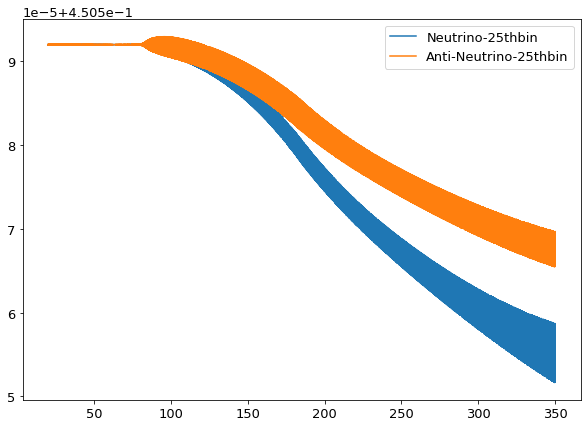

In [ ]:
plt.plot(t,0.5*(1+out[:,:,24,2]),label='Neutrino-25thbin')
plt.plot(t,0.5*(1+out[:,:,24,5]),label='Anti-Neutrino-25thbin')
#plt.axvline(x=130,color='violet',alpha=0.5,label='1st bin',linestyle='--')
#plt.axvline(x=125,color='indigo',alpha=0.5,label='5th bin',linestyle='--')
#plt.axvline(x=108,color='blue',alpha=0.5,label='10th bin',linestyle='--')
#plt.axvline(x=71,color='green',alpha=0.5,label='15th bin',linestyle='--')
#plt.axvline(x=232,color='r',alpha=0.5,label='20th bin',linestyle='--')
#plt.ylim(0,1)
plt.legend()
#plt.savefig('25thbin.jpeg')

In [ ]:
int_p_theta = (out.reshape(-1,SN_obj.n1,SN_obj.n2,6)).sum(axis=2)/(SN_obj.n2)
int_p_theta.shape

(450800, 1, 6)

In [ ]:
def plot_intP(bins=None):

    if bins==None:
      E_bins = np.arange(0,SN_obj.n2,1)
    else :
      E_bins = bins

    fig,ax = plt.subplots(1,2,figsize=(30,8))

    for i in E_bins:
        ax[0].plot(t,int_p_theta[:,i,2],label = r'$P_z$({})'.format(E[i]))
        ax[0].set_title(r'$<P_{\theta}>$', fontsize=15)
        ax[0].set_xlabel('r (km)')
        ax[0].legend()
    for i in E_bins:
        ax[1].plot(t,int_p_theta[:,i,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))
        ax[1].set_title(r'$<\overline{P_\theta}>$', fontsize=15)
        ax[1].set_xlabel('r (km)')
        ax[1].legend()

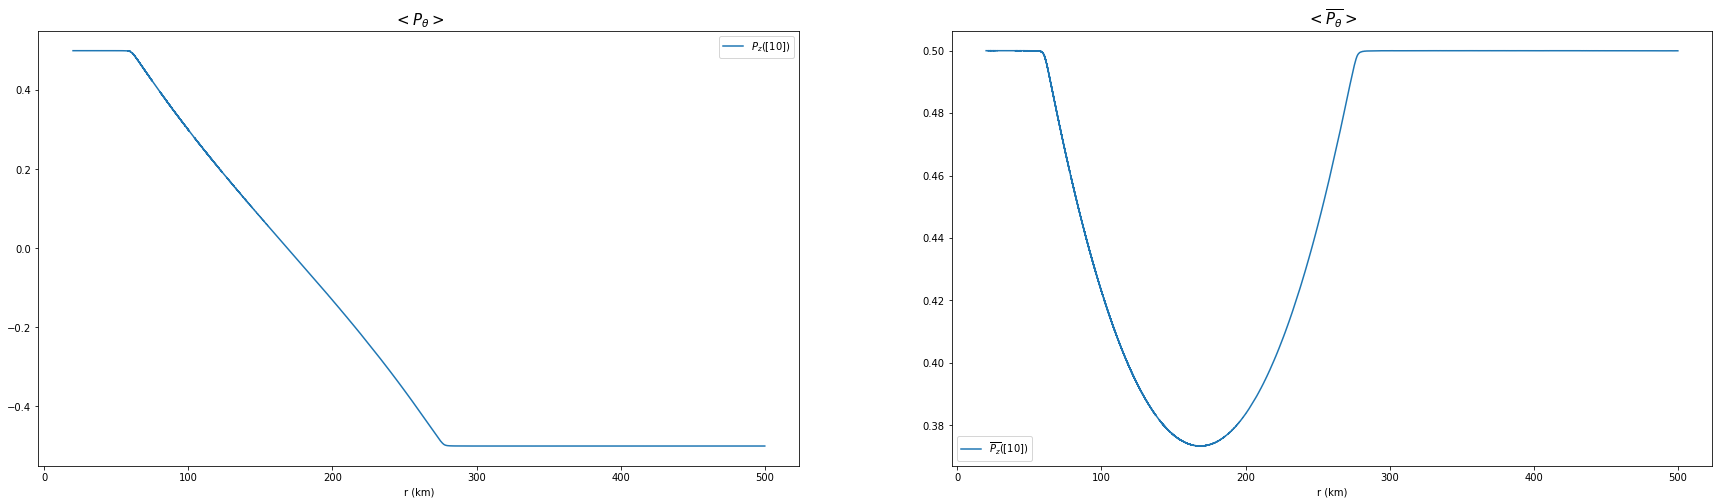

In [ ]:
plot_intP(bins=[0])

In [ ]:
P0i = SN_obj.P0.reshape(SN_obj.n1,SN_obj.n2,6).sum(axis=1)/SN_obj.n2
Pf = int_p_theta[:,:,2]
Pfb = int_p_theta[:,:,5]
Pi = P0i[:,2]
Pib = P0i[:,5]

In [ ]:
P_ee = 0.5*(1+ Pf/Pi)
P_eeb = 0.5*(1 + Pfb/Pib)

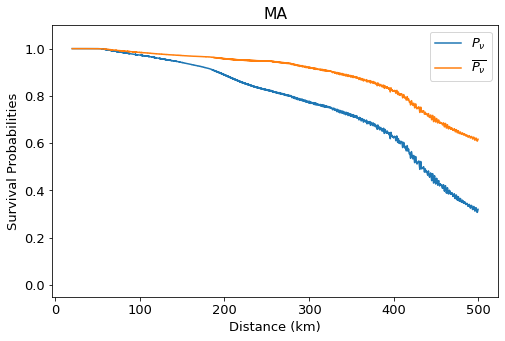

In [ ]:
plt.plot(t,P_ee, label = r'$P_{\nu}$')
plt.plot(t, P_eeb,label = r'$\overline{P_{\nu}}$')
plt.title(r'MA')# - 0.1cos$\bar{\nu}$ ')#| Inverted')
plt.xlabel('Distance (km)')
plt.ylabel('Survival Probabilities')
#plt.axvline(x=88,alpha=0.4,color='grey')
#plt.axvline(x=187,alpha=0.4,color='grey')
#plt.text(85,0,'x=88',color='grey',alpha=0.7,rotation=90)
#plt.text(188,0,'x=187',color='grey',alpha=0.7,rotation=270)
plt.ylim(-0.05,1.1)
#plt.axhline(0)
plt.legend()
#plt.savefig('MA_P_surv_0.1cosNubar_inv.pdf')

In [ ]:
out.shape

(751542, 1, 25, 6)

In [ ]:
def J_J_bar():
     if out is not None:

      I = SN_obj.I
      out_bin = out[:,0,:,:]
      int_D = SN_obj.I*out_bin
      #int_D = (I*int_p_theta).sum(axis=1)


      J     = int_D[:,:,0:3]
      J_bar = int_D[:,:,3:6]

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar

In [ ]:
J, J_bar = J_J_bar()
J.shape
int_E_z_1 = J[:,0,2] - J_bar[:,0,2]
int_E_z_5 = J[:,4,2] - J_bar[:,4,2]
int_E_z_12 = J[:,12,2] - J_bar[:,12,2]
int_E_z_15 = J[:,14,2] - J_bar[:,14,2]
int_E_z_20 = J[:,19,2] - J_bar[:,19,2]
int_E_z_25 = J[:,24,2] - J_bar[:,24,2]

#int_E_z = J[:,2] - J_bar[:,2]
potential_1 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_1*5*(pow(10,3)*np.exp(-(0.253/15)*t))  #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)
potential_5 =  11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_5*5*(pow(10,3)*np.exp(-(0.253/15)*t))
potential_12 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_12*5*(pow(10,3)*np.exp(-(0.253/15)*t))
potential_15 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_15*5*(pow(10,3)*np.exp(-(0.253/15)*t))
potential_20 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_20*5*(pow(10,3)*np.exp(-(0.253/15)*t))
potential_25 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_25*5*(pow(10,3)*np.exp(-(0.253/15)*t))


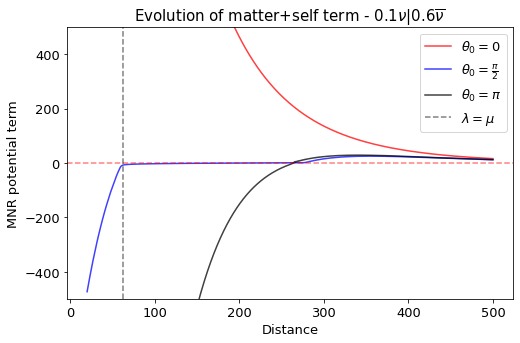

In [ ]:
plt.plot(t,potential_1,color = 'red',alpha=0.75, label=r'$\theta_{0}=0$')
#plt.plot(t,potential_5,color = 'indigo',alpha=0.75, label='5th bin')
plt.plot(t,potential_12,color = 'blue',alpha=0.75, label=r'$\theta_{0}=\frac{\pi}{2}$')
#plt.plot(t,potential_15,color = 'grey',alpha=0.75, label='15th bin')
#plt.plot(t,potential_20,color = 'orange',alpha=1, label='20th bin')
plt.plot(t,potential_25,color='black',alpha=0.75,label=r'$\theta_{0}=\pi$')
plt.title(r'Evolution of matter+self term - 0.1$\nu$|0.6$\overline{\nu}$',fontsize=15)
plt.xlabel('Distance',fontsize=13)
plt.axhline(y=0,alpha = 0.5,color='r',linestyle ='--')
plt.axvline(x=62,alpha=0.5,color='black',linestyle='--',label = r'$\lambda = \mu$')
#plt.axvspan(62,279,alpha=0.1,color='red',label='MNR region')
plt.ylabel('MNR potential term',fontsize=13)
plt.ylim(-500,500)
plt.legend()
#plt.savefig('ThreeAngles_Zoomed_Dz_evol_0.1Nu_0.6Nubar.pdf')

In [ ]:
t.shape

(450800,)

In [ ]:
t[409800]

250.01845359359723

In [ ]:
np.save('Nu_Inverted_0.9nu_286km.npy',out[421800,0,:,2])
np.save('Nubar_Inverted_0.9nu_286km.npy',out[421800,0,:,5])

In [ ]:
nu_norm = np.load('/content/Nu_Normal_0.9nu_286km.npy')
nubar_norm = np.load('/content/Nubar_Normal_0.9nu_286km.npy')

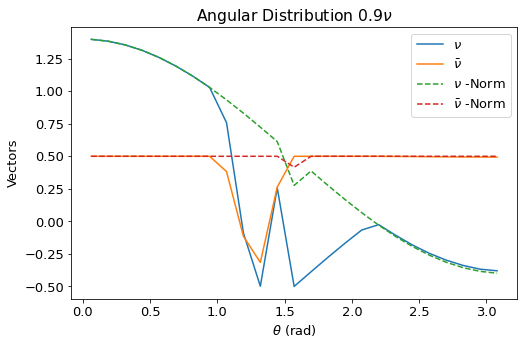

In [ ]:
plt.plot(SN_obj.thetas,out[421800,0,:,2],label=r'$\nu$')
plt.plot(SN_obj.thetas,out[421800,0,:,5],label=r'$\bar{\nu}$')
plt.plot(SN_obj.thetas,nu_norm,linestyle='--',label=r'$\nu$ -Norm')
plt.plot(SN_obj.thetas,nubar_norm,linestyle='--',label=r'$\bar{\nu}$ -Norm')
plt.title(r'Angular Distribution 0.9$\nu$')
plt.xlabel(r'$\theta$ (rad)')
plt.ylabel('Vectors')
plt.legend()
#plt.axhline(0.5,alpha=0.5)

#plt.savefig('Angular_dist_vectors_0.9nu.pdf')


# With Advection

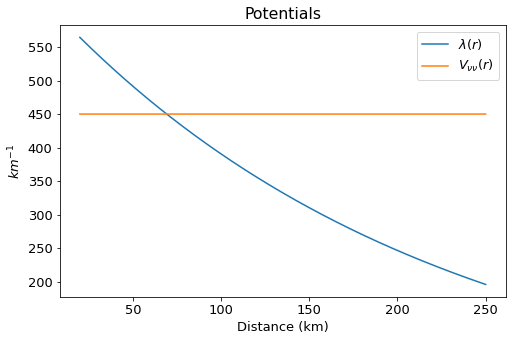

In [ ]:
r = np.linspace(20,250,10000)
lambd = 450 + 0*r
mu = 9*pow(10,3)*(0.275/2)*np.exp(-((0.115)/25)*r)#*0.5 #8*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*r)*0.5
plt.plot(r, mu*0.5,label=r'$\lambda(r)$')
plt.plot(r,lambd,label=r'$V_{\nu\nu}(r)$')
plt.xlabel('Distance (km)')
plt.ylabel(r'$km^{-1}$')
plt.title('Potentials')
plt.legend()
plt.savefig('PotentialsSample.jpeg')


Text(0.5, 0, 'Distance (km)')

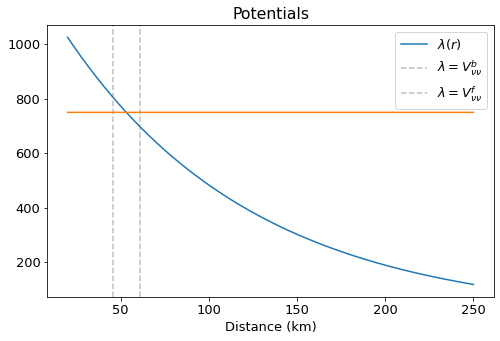

In [ ]:
d = np.linspace(20,250,10000)
#plt.plot(d,11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*d),label=r'$\lambda(r)$')
plt.plot(d, 9*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*d),label=r'$\lambda(r)$')
#plt.plot(d, 5*(pow(10,3)*np.exp(-(0.253/15)*d))*0.5,label=r'$V^{f}_{\nu\nu}(r)$')
#plt.plot(d, 5*(pow(10,3)*np.exp(-(0.253/15)*d))*0.45,label=r'$V^{b}_{\nu\nu}(r)$')
plt.plot(d,750 + 0*d)
plt.title('Potentials')
plt.axvline(46,linestyle='--',color='grey',alpha=0.5,label=r'$\lambda = V^{b}_{\nu\nu}$')
plt.axvline(61.2,linestyle='--',color='grey',alpha=0.5,label=r'$\lambda = V^{f}_{\nu\nu}$')
plt.legend()
plt.xlabel('Distance (km)')
#plt.savefig('Model_potential_BothDec_Adv.pdf')

In [ ]:
class SN_wrap_v2():
  def __init__(self,n1,n2,n3, r0, rf):

    self.n1    = n1           #E bins
    self.n2    = n2           #Theta bins
    self.n3    = n3
    self.r0    = r0
    self.rf    = rf
    if n1>1:
      self.E     = np.linspace(0,50,n1+1)[:-1]
      self.E    += (self.E[1]-self.E[0])*0.5
    else :
      self.E = np.array([10]).reshape(-1,1)

    if n2>1:
      self.thetas = np.arange(0,np.pi,3)#np.linspace(0,np.pi,n2+1)[:-1]
      #self.thetas += (self.thetas[1]-self.thetas[0])*0.5
      # self.thetas = self.thetas.reshape(-1,1)
    else :
      theta_max = np.pi
      theta_min = 0
      self.thetas = np.array([(theta_max - theta_min)/2]).reshape(-1,1)

    self.int_p_theta = 0

    I = []
    alpha   = 1
    beta_f  = 1.5
    beta_b  = 1.45

    for E_o in self.E:
      I.append(np.array([[alpha]*3 + [beta_f]*3] + [[alpha]*3 + [beta_b]*3]))  #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(I)
    self.I = np.tile(self.I.reshape(self.n1,1,2,6), (self.n3,1,1))

    self.t     = None
    self.out   = None

    P0 = []
    for theta_bin in self.thetas:
      P0 += self.P_init(theta_bin)*self.n1   #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

    self.P0 = np.tile(P0.reshape(self.n1,1, 2, 6),(self.n3,1,1))

    if self.n3>1:
      self.r     = np.linspace(r0,rf,self.n3+1)[:-1]
      self.r    += (self.r[1]-self.r[0])*0.5
    else :
      self.r = np.array([(rf-r0)/2]).reshape(-1,1)

    # Function yet to be decided
    self.P0*= 1 #self.r.reshape(1,self.n3,1,1)

    self.P0 = self.P0.reshape(-1)

    self.dcost = (np.cos(self.thetas[-1]) - np.cos(self.thetas[0]))/self.n2

  def P_init(self,theta):  # Generates initial values of P and Pbar
    if theta==0:
      return [0,0,0.5 ] + [0,0,0.5 ]
    else:
      return  [0,0,0.5]+  [0,0,0.5]
  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,self.n3,2,6), self.E,self.thetas

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.thetas,self.I)



  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  def SN_self_v3(self,t,P,E,thetas,I):   # Multiangle system definition

    dcost   = -self.dcost

    theta_v = 0.16                       # theta vacuum

    lambd   = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*self.r) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)         # Matter potential

    mu_p    = 5*(pow(10,3)*np.exp(-(0.253/15)*self.r)) #pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)

    P       = P.reshape(self.n1,self.n3,2,6)

    int_E = (I*P).sum(axis=0)           #Does element wise multiplication of xP and yP_b and stores it in the object

    int_E = int_E[:,:,0:3] - int_E[:,:,3:6]   #Separates xP and yP_b and subtracts it

    int_E = int_E.reshape(self.n3,2,1,3)
    E_bin = E
    theta_bin = thetas

    U = []

    for theta_bin in thetas:
      U.append((1-np.cos(theta_bin)*np.cos(thetas)))

    U = np.array(U) #Reshapes it into the correct shape
    U = np.tile(U.reshape(1,2,2,1),(self.n3,1,1,1))

    int_D = ((U*int_E)*dcost).sum(axis=1)
    #int_D = int_D.sum(axis=0)/self.n3 #integrate over r-bins (1,2,3)
    w = self.omega(E_bin)

    P1, P2 = P[:,:,0,0:3], P[:,:,0,3:6] #F
    P3, P4 = P[:,:,1,0:3], P[:,:,1,3:6] #B
    #shapes - (n1,n3,3)

    H1a = np.array([ w*np.sin(2*theta_v)  + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H1 = H1a + mu_p.reshape(self.n3,1)*int_D[:,0,:]

    H2a = np.array([ -w*np.sin(2*theta_v) + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H2 = H2a + mu_p.reshape(self.n3,1)*int_D[:,0,:]

    H3a = np.array([ w*np.sin(2*theta_v)  + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H3 = H3a + mu_p.reshape(self.n3,1)*int_D[:,1,:]

    H4a = np.array([ -w*np.sin(2*theta_v) + 0*t*lambd, 0 + 0*t*w*lambd ,
                    lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H4 = H4a + mu_p.reshape(self.n3,1)*int_D[:,1,:]

    h = (self.rf-self.r0)/self.n3

    dP1dr = 3e5*np.cross(H1, P1)  #F  #L/T * 1/L = 1/T
    dP2dr = 3e5*np.cross(H2, P2)  #F
    dP3dr = 3e5*np.cross(H3, P3)  #B
    dP4dr = 3e5*np.cross(H4, P4)  #B

    """
    for i in range(self.n3):
      if i == 0:
        dP1dr[:,i,:] -= 3e5*(P1[:,i+1,:] - P1[:,self.n3-1,:])/(2*h) #F
        dP2dr[:,i,:] -= 3e5*(P2[:,i+1,:] - P2[:,self.n3-1,:])/(2*h) #F

        dP3dr[:,i,:] += 3e5*(P3[:,i+1,:] - P3[:,self.n3-1,:])/(2*h) #B
        dP4dr[:,i,:] += 3e5*(P4[:,i+1,:] - P4[:,self.n3-1,:])/(2*h) #B
      elif i== self.n3-1:
        dP1dr[:,i,:] -= 3e5*(P1[:,0,:] - P1[:,i-1,:])/(2*h) #F
        dP2dr[:,i,:] -= 3e5*(P2[:,0,:] - P2[:,i-1,:])/(2*h) #F

        dP3dr[:,i,:] += 3e5*(P3[:,0,:] - P3[:,i-1,:])/(2*h) #B
        dP4dr[:,i,:] += 3e5*(P4[:,0,:] - P4[:,i-1,:])/(2*h) #B
      else:
        dP1dr[:,i,:] -= 3e5*(P1[:,i+1,:] - P1[:,i-1,:])/(2*h) #F
        dP2dr[:,i,:] -= 3e5*(P2[:,i+1,:] - P2[:,i-1,:])/(2*h) #F

        dP3dr[:,i,:] += 3e5*(P3[:,i+1,:] - P3[:,i-1,:])/(2*h) #B
        dP4dr[:,i,:] += 3e5*(P4[:,i+1,:] - P4[:,i-1,:])/(2*h) #B

    """
    dP1dr = dP1dr.reshape(1,self.n3,1,3)
    dP2dr = dP2dr.reshape(1,self.n3,1,3)  #F
    dP3dr = dP3dr.reshape(1,self.n3,1,3)  #B
    dP4dr = dP4dr.reshape(1,self.n3,1,3)  #B


    dPdtf =  np.concatenate((dP1dr,dP2dr), axis = 3)
    dPdtb =  np.concatenate((dP3dr,dP4dr), axis = 3)

    dPdt = np.concatenate((dPdtf,dPdtb),axis=2)

    #Status
    if 3e5*t >1 + 3e5*self.t_prev:
      print(t*3e5)
      self.t_prev = t

    return dPdt

  def solver(self):

    t0 = 0 #self.r0/3e8
    tf = 2.3333333333333332e-05#6.666666666666667e-05 #self.rf/3e8
    t_span=(t0,tf)
    self.t_prev =t0

    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol=1e-6,atol=1e-6)

    t_values = []
    y_values = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)

      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,self.n3,2,6)

    #costheta = np.cos(self.thetas).reshape(1,1,-1,1)
    self.int_p_theta = (self.out.reshape(-1,self.n1,self.n3,2,6)).sum(axis=3)/2

    self.int_p_theta

    return self.t, self.out

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n2,1)
    else :
      E_bins = bins
    for j in range(self.n2):
      for i in E_bins:
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,2],label = r'$P_z$({})'.format(E[i]))
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))

      plt.title(f'Theta : {theta[j][0]}')
      plt.xlabel('r (km)')
      plt.legend()
      plt.show()
      plt.close()

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I[:,:,0,:]
      int_D = (I*self.int_p_theta).sum(axis=1)

      J     = int_D[:,0:3]*dE/2
      J_bar = int_D[:,3:6]*dE/2

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar

In [ ]:
SN_obj = SN_wrap_v2(n1=1,n2 = 2,n3 = 500,r0 = 40, rf = 65)
P0, E, theta = SN_obj.init_E_P_theta()

In [ ]:
25/1000

0.025

In [ ]:
SN_obj.r[177]-SN_obj.r[176]

0.025000000000005684

In [ ]:
10/3e5

3.3333333333333335e-05

In [ ]:
#Normalization check
P_initial = SN_obj.P0.reshape(SN_obj.n1,SN_obj.n2,SN_obj.n3,6)
dcost = -SN_obj.dcost

(P_initial*dcost).sum(axis=1)

array([[[0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625],
        [0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625],
        [0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625],
        ...,
        [0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625],
        [0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625],
        [0.        , 0.        , 0.99499625, 0.        , 0.        ,
         0.99499625]]])

In [ ]:
t, out = SN_obj.solver()

1.2565128226658553
3.350700860442281
4.350704965600841
5.350731230289145
6.350772362280555


In [ ]:
#Angle integrated polarization vectors - Final
int_p_theta = (out.reshape(-1,SN_obj.n1,SN_obj.n3,2,6)).sum(axis=3)/2
int_p_theta.shape


(15866, 1, 500, 6)

In [ ]:
#Angle integrated polarization vectors - Final
int_p_r = (out.reshape(-1,SN_obj.n1,SN_obj.n3,2,6)).sum(axis=(2,3))/(2*SN_obj.n3)
int_p_r.shape

(15866, 1, 6)

In [ ]:
out.shape

(3096, 1, 200, 2, 6)

In [ ]:
np.save('out_withoutAdvection.npy',out)
np.save('t_withoutAdvection.npy',t)

In [ ]:
out_adv = np.load('/content/out_withoutAdvection.npy')
t_adv   = np.load('/content/t_withoutAdvection.npy')

In [ ]:
int_p_theta_adv = (out_adv.reshape(-1,SN_obj.n1,SN_obj.n3,2,6)).sum(axis=3)/2
int_p_theta_adv.shape

NameError: ignored

In [ ]:
t_adv[1200]

5.119334138127989e-06

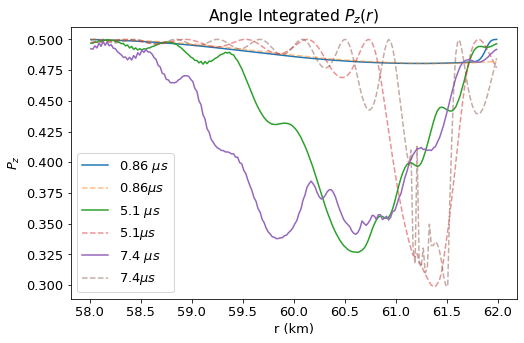

In [ ]:
plt.title(r'Angle Integrated $P_{z}(r)$')
plt.plot(SN_obj.r,int_p_theta[200,0,:,2],label=r'$0.86\ \mu s$ ')
plt.plot(SN_obj.r,int_p_theta_adv[200,0,:,2],alpha=0.5,label = r'$0.86 \mu s$', linestyle='--')
plt.plot(SN_obj.r,int_p_theta[1200,0,:,2],label=r'$5.1\ \mu s$ ')
plt.plot(SN_obj.r,int_p_theta_adv[1200,0,:,2],alpha=0.5,label = r'$5.1 \mu s$', linestyle='--')
plt.plot(SN_obj.r,int_p_theta[1736,0,:,2],label=r'$7.4\ \mu s$ ')
plt.plot(SN_obj.r,int_p_theta_adv[1750,0,:,2],alpha=0.5,label = r'$7.4 \mu s$', linestyle='--')
plt.xlabel('r (km)')
plt.ylabel(r'$P_{z}$')
plt.legend()
#plt.axhline(0.5)
plt.savefig('Pz_comparison.pdf')

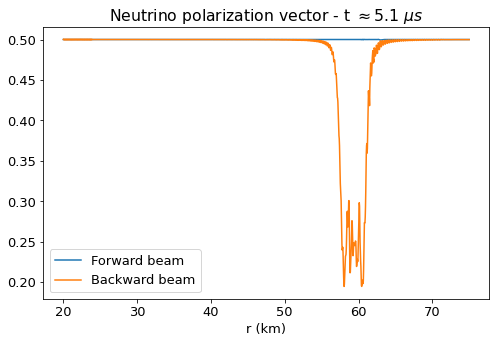

In [ ]:
plt.plot(SN_obj.r,out[4299,0,:,0,2],label='Forward beam')
plt.plot(SN_obj.r,out[4299,0,:,1,2],label='Backward beam')
#plt.axvline(94,linestyle='--',color='grey',label=r'$\lambda = \mu$')
plt.title(r'Neutrino polarization vector - t $\approx 5.1\ \mu s$')
plt.xlabel('r (km)')
plt.legend()
#plt.savefig('Pvec_5.1mus.pdf')

In [ ]:
def plot_intP(bins=None):

    if bins==None:
      E_bins = np.arange(0,SN_obj.n3,1)
    else :
      E_bins = bins

    fig,ax = plt.subplots(1,2,figsize=(30,8))

    for i in E_bins:
        ax[0].plot(t*3e5,int_p_theta[:,:,i,2],label = r'$P_z$({})'.format(np.round(SN_obj.r[i]),2))
        ax[0].set_title(r'$<P_{\theta}>$', fontsize=25)
        ax[0].set_xlabel('t (km)')
        ax[0].legend()
    for i in E_bins:
        ax[1].plot(t*3e5,int_p_theta[:,:,i,5],label = r'$\overline{P_z}$' + '({})'.format(np.round(SN_obj.r[i]),2) )
        ax[1].set_title(r'$<\overline{P_\theta}>$', fontsize=25)
        ax[1].set_xlabel('t (km)')
        ax[1].legend()
    #plt.savefig('P_Pbar_r_dep_bins_t15km_withAdv.pdf')

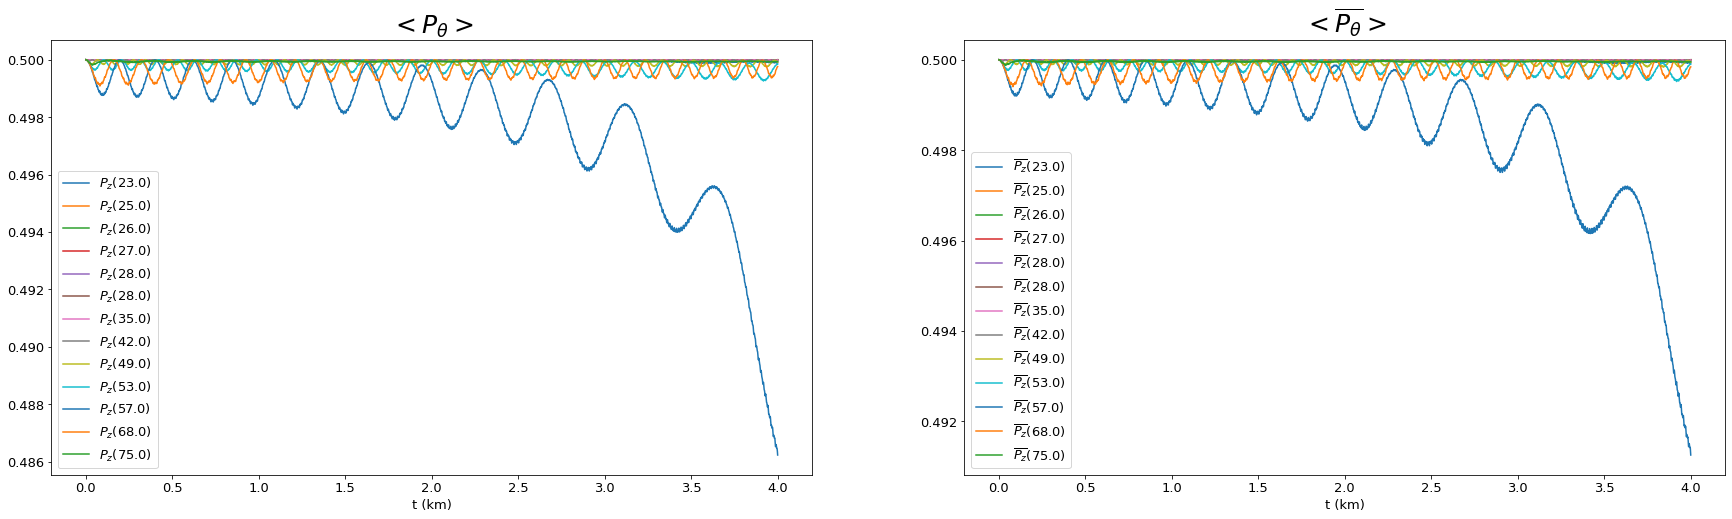

In [ ]:
plot_intP(bins=[89,139,169,199,209,229,399,599,799,899,999,1299,1499])

In [ ]:
t.shape

(4300,)

In [ ]:
t_average_p_theta = int_p_theta.sum(axis=0)/4300
t_average_p_theta.shape

(1, 1500, 6)

In [ ]:
P0_av = SN_obj.P0.reshape(-1,SN_obj.n1,SN_obj.n3,2,6).sum(axis=3)/2
P0_av.shape

(1, 1, 1500, 6)

In [ ]:
Pf_t = t_average_p_theta[0,:,2]
Pfb_t = t_average_p_theta[0,:,5]

Pi_t = P0_av[0,0,:,2]
Pib_t = P0_av[0,0,:,5]

In [ ]:
P_ee_t = 0.5*(1+ Pf_t/Pi_t)
P_eeb_t = 0.5*(1 + Pfb_t/Pib_t)

In [ ]:
np.save('P_surv_withAdvection.npy',P_ee_t)
np.save('Pb_surv_withAdvection.npy',P_eeb_t)

In [ ]:
P_ee_t_withAdv = np.load('/content/P_surv_withAdvection.npy')
P_eeb_t_withAdv = np.load('/content/Pb_surv_withAdvection.npy')

(50.0, 75.0)

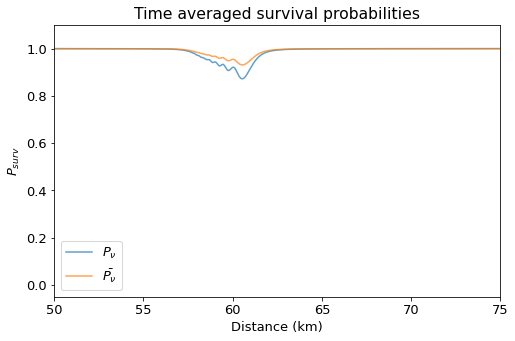

In [ ]:
#plt.plot(SN_obj.r,P_ee_t_withAdv, label=r'$P_{\nu}$')
#plt.plot(SN_obj.r, P_eeb_t_withAdv, label=r'$\bar{P_{\nu}}$')
plt.plot(SN_obj.r,P_ee_t,alpha=0.7, label=r'$P_{\nu}$')#, linestyle='--')
plt.plot(SN_obj.r, P_eeb_t,alpha=0.7, label=r'$\bar{P_{\nu}}$')#,linestyle='--')

plt.title('Time averaged survival probabilities')
plt.xlabel('Distance (km)')
plt.ylabel(r'$P_{surv}$')
plt.ylim(-0.05,1.1)
plt.legend()
plt.xlim(50,75)
#plt.savefig('P_surv_tave_Comparison.pdf')


In [ ]:
#Angle integrated initial values
P0i = SN_obj.P0.reshape(-1,SN_obj.n1,SN_obj.n3,2,6).sum(axis=(2,3))/(2*SN_obj.n3)
P0i.shape

(1, 1, 6)

In [ ]:
Pf = int_p_r[:,0,2]
Pfb = int_p_r[:,0,5]
Pi = P0i[:,0,2]
Pib = P0i[:,0,5]

In [ ]:
P_ee = 0.5*(1+ Pf/Pi)
P_eeb = 0.5*(1 + Pfb/Pib)

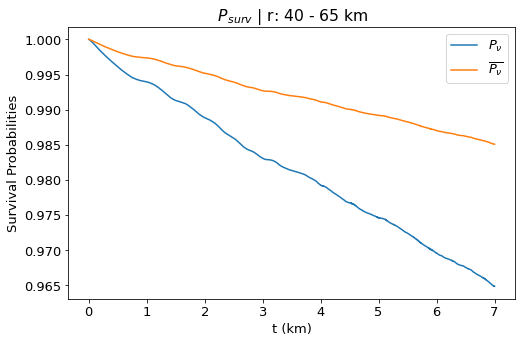

In [ ]:
#Survival Probability plot generation

plt.plot(t*3e5,P_ee, label = r'$P_{\nu}$')
plt.plot(t*3e5, P_eeb,label = r'$\overline{P_{\nu}}$')
plt.title(r' $P_{surv}$ | r: 40 - 65 km ')#| $\lambda(r),\mu(r)\ | \beta_{f} = 1.45 |\ \beta_{b} = 1.65$')#1|1.5|1cos')
plt.xlabel('t (km)')
plt.ylabel('Survival Probabilities')
#plt.axvline(x=35,alpha=0.4,color='grey')
#plt.axvline(x=275,alpha=0.4,color='grey')
#plt.text(85,0,'x=88',color='grey',alpha=0.7,rotation=90)
#plt.xlim(0,350)
#plt.text(188,0,'x=187',color='grey',alpha=0.7,rotation=270)
#plt.ylim(-0.05,1.1)

plt.legend()
plt.savefig('P_surv_WithAdvection_Zoomed_t7km_40-65.pdf')

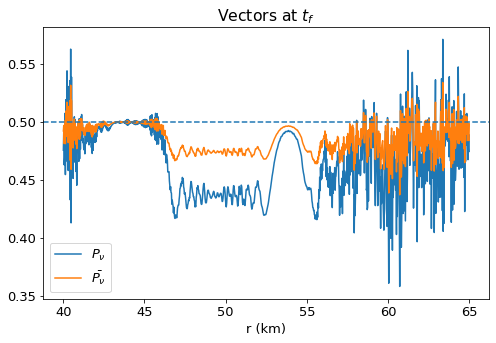

In [ ]:
plt.plot(SN_obj.r,int_p_theta[-1,0,:,2],label=r'$P_{\nu}$')
plt.plot(SN_obj.r,int_p_theta[-1,0,:,5],label=r'$\bar{P_{\nu}}$')
plt.title(r'Vectors at $t_{f}$')
plt.xlabel('r (km)')
plt.legend()
#plt.xlim(55,65)
plt.axhline(0.5,linestyle='--')
#plt.savefig('P_at_t_f_withoutAdv_7kmt_40-65.pdf')

In [ ]:
P_ee_raw = 0.5*(1 + int_p_theta[:,0,:,2]/P0i[:,0,2])
P_eeb_raw = 0.5*(1 + int_p_theta[:,0,:,5]/P0i[:,0,5])
from matplotlib import ticker, cm

In [ ]:
levels = np.linspace(0,1,100)
ticks = np.arange(0,1,0.1)

KeyboardInterrupt: ignored

Error in callback <function install_repl_displayhook.<locals>.post_execute at 0x7fd23b7490e0> (for post_execute):


KeyboardInterrupt: ignored

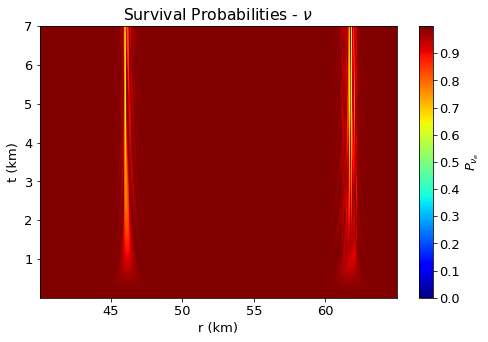

In [ ]:
plt.pcolormesh(SN_obj.r,t*3e5,P_ee_raw,cmap='jet',vmax=1,vmin=0)
plt.colorbar(ticks=ticks,label=r'$P_{\nu_{e}}$')
plt.xlabel('r (km)')
plt.ylabel('t (km)')
plt.title(r'Survival Probabilities - $\nu$')
plt.savefig('P_surv_Nu_withouAdv_model_bothDec.pdf')

Text(0.5, 1.0, 'Survival Probabilities - $\\bar{\\nu}$')

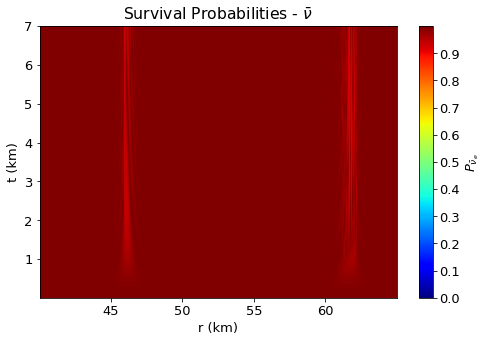

In [ ]:
plt.pcolormesh(SN_obj.r,t*3e5,P_eeb_raw,cmap='jet',vmax=1,vmin=0)
plt.colorbar(ticks=ticks,label=r'$P_{\bar{\nu}_{e}}$')
plt.xlabel('r (km)')
plt.ylabel('t (km)')
plt.title(r'Survival Probabilities - $\bar{\nu}$')
plt.savefig('P_surv_Nubar_withoutAdv_model_bothDec.pdf')

In [ ]:
int_p_r_notheta = (out.reshape(-1,SN_obj.n1,SN_obj.n3,2,6)).sum(axis=2)/SN_obj.n3
int_p_r_notheta.shape

(7808, 1, 2, 6)

In [ ]:
SN_obj.I.shape

(1, 1000, 2, 6)

In [ ]:
def J_J_bar():
     if out is not None:

      I = SN_obj.I[0,0,1,:]

      out_bin = int_p_r_notheta[:,0,1,:]

      int_D = I*out_bin #(6) * (86000,6)
      #int_D = (I*int_p_theta).sum(axis=1)

      #print(int_D.shape)
      J     = int_D[:,0:3]
      J_bar = int_D[:,3:6]

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar

In [ ]:
J, J_bar = J_J_bar()


In [ ]:
int_E_z_f_1 = J[:,2] - J_bar[:,2]

In [ ]:
int_E_z_b_1 = J[:,2] - J_bar[:,2]

In [ ]:

#J.shape
#int_E_z_f_1 = J[:,:,0,0,2] - J_bar[:,:,0,0,2]
#int_E_z_b_1 = J[:,:,0,1,2] - J_bar[:,:,0,1,2]

#int_E_z_12 = J[:,12,2] - J_bar[:,12,2]
#int_E_z_15 = J[:,14,2] - J_bar[:,14,2]
#int_E_z_20 = J[:,19,2] - J_bar[:,19,2]
#int_E_z_25 = J[:,24,2] - J_bar[:,24,2]

#int_E_z = J[:,2] - J_bar[:,2]
potential_1 =   11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t*3e5)+ 2*int_E_z_f_1*5*(pow(10,3)*np.exp(-(0.253/15)*t*3e5))  #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t) #latest-11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)
potential_5 =   11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t*3e5) + 2*int_E_z_b_1*5*(pow(10,3)*np.exp(-(0.253/15)*t*3e5)) #11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t) 9*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)
#potential_12 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_12*5*(pow(10,3)*np.exp(-(0.253/15)*t))
#potential_15 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_15*5*(pow(10,3)*np.exp(-(0.253/15)*t))
#potential_20 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_20*5*(pow(10,3)*np.exp(-(0.253/15)*t))
#potential_25 = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*t)  + 2*int_E_z_25*5*(pow(10,3)*np.exp(-(0.253/15)*t))


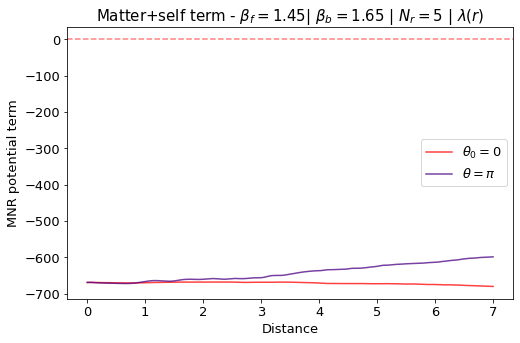

In [ ]:
#Evolution of potentials plot generation

plt.plot(t*3e5,potential_1,color = 'red',alpha=0.75, label=r'$\theta_{0}=0$')
plt.plot(t*3e5,potential_5,color = 'indigo',alpha=0.75, label=r'$\theta = \pi$')
#plt.plot(t, (potential_1 + potential_5) - (potential_1 - potential_5)  ,label='difference')
#plt.plot(t,potential_12,color = 'blue',alpha=0.75, label=r'$\theta_{0}=\frac{\pi}{2}$')
#plt.plot(t,potential_15,color = 'grey',alpha=0.75, label='15th bin')
#plt.plot(t,potential_20,color = 'orange',alpha=1, label='20th bin')
#plt.plot(t,potential_25,color='black',alpha=0.75,label=r'$\theta_{0}=\pi$')
plt.title(r'Matter+self term - $\beta_{f} = 1.45 |\ \beta_{b} = 1.65$ | $N_{r} = 5$ | $\lambda(r)$',fontsize=15)
plt.xlabel('Distance',fontsize=13)
plt.axhline(y=0,alpha = 0.5,color='r',linestyle ='--')
#plt.axvline(x=93,alpha=0.5,color='black',linestyle='--',label = r'$\lambda = \mu$')
#plt.axvspan(62,279,alpha=0.1,color='red',label='MNR region')
plt.ylabel('MNR potential term',fontsize=13)
#plt.ylim(-500,500)
plt.legend()
#plt.savefig('Zoomed_Dz_evol_Adv_MatterCase2_1.45_1.65.pdf')

In [ ]:
"""
class SN_wrap_v2():
  def __init__(self,n1,n2,n3, r0, rf):

    self.n1    = n1           #E bins
    self.n2    = n2           #Theta bins
    self.n3    = n3
    self.r0    = r0
    self.rf    = rf
    if n1>1:
      self.E     = np.linspace(0,50,n1+1)[:-1]
      self.E    += (self.E[1]-self.E[0])*0.5
    else :
      self.E = np.array([10]).reshape(-1,1)

    if n2>1:
      self.thetas = np.arange(0,np.pi,3)#np.linspace(0,np.pi,n2+1)[:-1]
      #self.thetas += (self.thetas[1]-self.thetas[0])*0.5
      # self.thetas = self.thetas.reshape(-1,1)
    else :
      theta_max = np.pi
      theta_min = 0
      self.thetas = np.array([(theta_max - theta_min)/2]).reshape(-1,1)

    self.int_p_theta = 0

    I = []
    alpha   = 1
    beta_f  = 1.5
    beta_b  = 1.5

    for E_o in self.E:
      I.append(np.array([[alpha]*3 + [beta_f]*3] + [[alpha]*3 + [beta_b]*3]))  #Creates an tensor with 3 copies of x's and y's to be multiplied by the P's and Pbar's

    self.I = np.array(I)
    self.I = np.tile(self.I.reshape(self.n1,1,2,6), (self.n3,1,1))

    self.t     = None
    self.out   = None

    P0 = []
    for theta_bin in self.thetas:
      P0 += self.P_init(theta_bin)*self.n1   #Makes copies of initial value for the T bins and E bins = P0
    P0 = np.array(P0)
    self.P0 = P0

    self.P0 = np.tile(P0.reshape(self.n1,1, 2, 6),(self.n3,1,1))

    if self.n3>1:
      self.r     = np.linspace(r0,rf,self.n3+1)[:-1]
      self.r    += (self.r[1]-self.r[0])*0.5
    else :
      self.r = np.array([(rf-r0)/2]).reshape(-1,1)

    # Function yet to be decided
    self.P0*= 1 #self.r.reshape(1,1,self.n3,1)

    self.P0 = self.P0.reshape(-1)

    self.dcost = (np.cos(self.thetas[-1]) - np.cos(self.thetas[0]))/self.n2

  def P_init(self,theta):  # Generates initial values of P and Pbar
    if theta==0:
      return [0,0,0.5 ] + [0,0,0.5 ]
    else:
      return  [0,0,0.5]+  [0,0,0.5]
  def init_E_P_theta(self):
    return self.P0.reshape(self.n1,self.n3,2,6), self.E,self.thetas

  def __call__(self,t,P):

   return self.SN_self_v3(t,P,self.E,self.thetas,self.I)



  def omega(self,E):                              # Vacuum potential calc func
    dm2 = 2 * 10**-9                              # In terms of eV
    conv = 0.506 * 10**10                         # conversion factor eV -> 1/km
    w = (dm2 * conv)/(2*E)
    return w

  def SN_self_v3(self,t,P,E,thetas,I):   # Multiangle system definition

    dcost   = -self.dcost

    theta_v = 0.16                       # theta vacuum

    lambd   = 11.5*pow(10,3)*(0.275/2)*np.exp(-((0.235)/25)*self.r) #2.5*pow(10,4)*(0.235/2)*np.exp(-((1.5*0.235/2)/20)*t)         # Matter potential

    mu_p    = 5*(pow(10,3)*np.exp(-(0.253/15)*self.r)) #pow(10,4)*2.53*np.exp(-(1.5*0.253/15)*t)

    P       = P.reshape(self.n1,self.n3,2,6)

    int_E = (I*P).sum(axis=0)           #Does element wise multiplication of xP and yP_b and stores it in the object

    int_E = int_E[:,:,0:3] - int_E[:,:,3:6]   #Separates xP and yP_b and subtracts it

    int_E = int_E.reshape(self.n3,2,1,3)
    E_bin = E
    theta_bin = thetas

    U = []

    for theta_bin in thetas:
      U.append((1-np.cos(theta_bin)*np.cos(thetas)))

    U = np.array(U) #Reshapes it into the correct shape
    U = np.tile(U.reshape(1,2,2,1),(self.n3,1,1,1))

    int_D = ((U*int_E)*dcost).sum(axis=1)
    int_D = int_D.sum(axis=0)/self.n3 #integrate over r-bins (1,2,3) int_D.reshape(1,self.n2,self.n3,3).sum(axis=0)
    w = self.omega(E_bin)

    P1, P2 = P[:,:,0,0:3], P[:,:,0,3:6] #F
    P3, P4 = P[:,:,1,0:3], P[:,:,1,3:6] #B
    #shapes - (n1,n3,3)

    H1a = np.array([ w*np.sin(2*theta_v)  + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H1 = H1a + mu_p.reshape(self.n3,1)*int_D[0,:]

    H2a = np.array([ -w*np.sin(2*theta_v) + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H2 = H2a + mu_p.reshape(self.n3,1)*int_D[0,:]

    H3a = np.array([ w*np.sin(2*theta_v)  + 0*t*lambd, 0 + 0*t*w*lambd,
                    lambd - w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H3 = H3a + mu_p.reshape(self.n3,1)*int_D[1,:]

    H4a = np.array([ -w*np.sin(2*theta_v) + 0*t*lambd, 0 + 0*t*w*lambd ,
                    lambd + w*np.cos(2*theta_v)]).T.reshape(self.n1,self.n3,3)
    H4 = H4a + mu_p.reshape(self.n3,1)*int_D[1,:]

    #print(H1[:,0,:])
    #print(...)
    #print(H1[:,1,:])

    #print(H1[:,2,:])

    dP1dr = np.cross(H1, P1)  #F
    dP2dr = np.cross(H2, P2)  #F
    dP3dr = np.cross(H3, P3)  #B
    dP4dr = np.cross(H4, P4)  #B
    #print(dP1dr)
    #print(dP1dr.shape)
    h = (self.rf-self.r0)/self.n3

    #dP1dr -= np.gradient(P1,axis=1)
    #dP2dr -= np.gradient(P2,axis=1)
    #dP3dr += np.gradient(P3,axis=1)
    #dP4dr += np.gradient(P4,axis=1)
    #print(dP1dr,shape)

    # Advective term
    for i in range(self.n3):
      if i == 0:
        dP1dr[:,i,:] += (P1[:,i+1,:] - P1[:,i,:])/(h) #F
        dP2dr[:,i,:] += (P2[:,i+1,:] - P2[:,i,:])/(h) #F

        dP3dr[:,i,:] -= (P3[:,i+1,:] - P3[:,i,:])/(h) #B
        dP4dr[:,i,:] -= (P4[:,i+1,:] - P4[:,i,:])/(h) #B
      elif i== self.n3-1:
        dP1dr[:,i,:] += (P1[:,i,:] - P1[:,i-1,:])/(h) #F
        dP2dr[:,i,:] += (P2[:,i,:] - P2[:,i-1,:])/(h) #F

        dP3dr[:,i,:] -= (P3[:,i,:] - P3[:,i-1,:])/(h) #B
        dP4dr[:,i,:] -= (P4[:,i,:] - P4[:,i-1,:])/(h) #B
      else:
        dP1dr[:,i,:] += (P1[:,i+1,:] - P1[:,i-1,:])/(2*h) #F
        dP2dr[:,i,:] += (P2[:,i+1,:] - P2[:,i-1,:])/(2*h) #F

        dP3dr[:,i,:] -= (P3[:,i+1,:] - P3[:,i-1,:])/(2*h) #B
        dP4dr[:,i,:] -= (P4[:,i+1,:] - P4[:,i-1,:])/(2*h) #B

    #print(dP1dr.shape) shape - (1,1,2,3)?
    #print(dP3dr)
    #print(dP1dr)

    dP1dr = dP1dr.reshape(1,self.n3,1,3)  #F
    dP2dr = dP2dr.reshape(1,self.n3,1,3)  #F
    dP3dr = dP3dr.reshape(1,self.n3,1,3)  #B
    dP4dr = dP4dr.reshape(1,self.n3,1,3)  #B

    dPdtf =  np.concatenate((dP1dr,dP2dr), axis = 3)
    dPdtb =  np.concatenate((dP3dr,dP4dr), axis = 3)

    dPdt = np.concatenate((dPdtf,dPdtb),axis=2)

    return dPdt

  def solver(self):

    t0 = self.r0
    tf = self.rf
    t_span=(t0,tf)


    sol = RK45(self,t0,self.P0,tf,vectorized=True,rtol=1e-6,atol=1e-6)

    t_values = []
    y_values = []

    while(True):
      # Get solution step state
      sol.step()
      t_values.append(sol.t)
      y_values.append(sol.y)

      # Break loop after modeling is finished
      if sol.status == 'finished':
        break

    t   = np.array(t_values)
    out = np.array(y_values)

    self.t = t
    self.out = out.reshape(-1,self.n1,self.n3,2,6)

    #costheta = np.cos(self.thetas).reshape(1,1,-1,1)
    self.int_p_theta = (self.out.reshape(-1,self.n1,self.n3,2,6)).sum(axis=3)/2

    self.int_p_theta

    return self.t, self.out

  def show_plot(self,bins=None):
    if bins==None:
      E_bins = np.arange(0,self.n2,1)
    else :
      E_bins = bins
    for j in range(self.n2):
      for i in E_bins:
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,2],label = r'$P_z$({})'.format(E[i]))
        plt.plot(t,self.out.reshape(-1,self.n1,self.n2,6)[:,i,j,5],label = r'$\overline{P_z}$' + '({})'.format(E[i]))

      plt.title(f'Theta : {theta[j][0]}')
      plt.xlabel('r (km)')
      plt.legend()
      plt.show()
      plt.close()

  def J_J_bar(self):
     if self.out is not None:
      dE = 2*self.E[0]
      I = self.I[:,:,0,:]
      int_D = (I*self.int_p_theta).sum(axis=1)

      J     = int_D[:,0:3]*dE/2
      J_bar = int_D[:,3:6]*dE/2

      #Diff = (J-J_bar)*(2*np.pi/(self.A + self.B)*dE).sum(axis=0)

      return J,J_bar
"""